In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import accuracy_score

In [2]:
# i uploaded the dataset for the final assignment to github because i'm using vscode to do the final assignment 
url = "https://raw.githubusercontent.com/VincentHalim11/GCI-final-test-dataset/refs/heads/main/WA_Fn-UseC_-HR-Employee-Attrition.csv"
df = pd.read_csv(url)
df.head()

,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EmployeeCount,EmployeeNumber,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
0,41,Yes,Travel_Rarely,1102,Sales,1,2,Life Sciences,1,1,...,1,80,0,8,0,1,6,4,0,5
1,49,No,Travel_Frequently,279,Research & Development,8,1,Life Sciences,1,2,...,4,80,1,10,3,3,10,7,1,7
2,37,Yes,Travel_Rarely,1373,Research & Development,2,2,Other,1,4,...,2,80,0,7,3,3,0,0,0,0
3,33,No,Travel_Frequently,1392,Research & Development,3,4,Life Sciences,1,5,...,3,80,0,8,3,3,8,7,3,0
4,27,No,Travel_Rarely,591,Research & Development,2,1,Medical,1,7,...,4,80,1,6,3,3,2,2,2,2


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 35 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EmployeeCount             1470 non-null   int64 
 9   EmployeeNumber            1470 non-null   int64 
 10  EnvironmentSatisfaction   1470 non-null   int64 
 11  Gender                    1470 non-null   object
 12  HourlyRate                1470 non-null   int64 
 13  JobInvolvement            1470 non-null   int64 
 14  JobLevel                

In [4]:
df.describe()

,Age,DailyRate,DistanceFromHome,Education,EmployeeCount,EmployeeNumber,EnvironmentSatisfaction,HourlyRate,JobInvolvement,JobLevel,...,RelationshipSatisfaction,StandardHours,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
count,1470.000000,1470.000000,1470.000000,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,...,1470.000000,1470.0,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000,1470.000000
mean,36.923810,802.485714,9.192517,2.912925,1.0,1024.865306,2.721769,65.891156,2.729932,2.063946,...,2.712245,80.0,0.793878,11.279592,2.799320,2.761224,7.008163,4.229252,2.187755,4.123129
std,9.135373,403.509100,8.106864,1.024165,0.0,602.024335,1.093082,20.329428,0.711561,1.106940,...,1.081209,0.0,0.852077,7.780782,1.289271,0.706476,6.126525,3.623137,3.222430,3.568136
min,18.000000,102.000000,1.000000,1.000000,1.0,1.000000,1.000000,30.000000,1.000000,1.000000,...,1.000000,80.0,0.000000,0.000000,0.000000,1.000000,0.000000,0.000000,0.000000,0.000000
25%,30.000000,465.000000,2.000000,2.000000,1.0,491.250000,2.000000,48.000000,2.000000,1.000000,...,2.000000,80.0,0.000000,6.000000,2.000000,2.000000,3.000000,2.000000,0.000000,2.000000
50%,36.000000,802.000000,7.000000,3.000000,1.0,1020.500000,3.000000,66.000000,3.000000,2.000000,...,3.000000,80.0,1.000000,10.000000,3.000000,3.000000,5.000000,3.000000,1.000000,3.000000
75%,43.000000,1157.000000,14.000000,4.000000,1.0,1555.750000,4.000000,83.750000,3.000000,3.000000,...,4.000000,80.0,1.000000,15.000000,3.000000,3.000000,9.000000,7.000000,3.000000,7.000000
max,60.000000,1499.000000,29.000000,5.000000,1.0,2068.000000,4.000000,100.000000,4.000000,5.000000,...,4.000000,80.0,3.000000,40.000000,6.000000,4.000000,40.000000,18.000000,15.000000,17.000000


In [5]:
unique_values = {col: df[col].unique() for col in df.columns}
display(unique_values)

{'Age': array([41, 49, 37, 33, 27, 32, 59, 30, 38, 36, 35, 29, 31, 34, 28, 22, 53,
        24, 21, 42, 44, 46, 39, 43, 50, 26, 48, 55, 45, 56, 23, 51, 40, 54,
        58, 20, 25, 19, 57, 52, 47, 18, 60], dtype=int64),
 'Attrition': array(['Yes', 'No'], dtype=object),
 'BusinessTravel': array(['Travel_Rarely', 'Travel_Frequently', 'Non-Travel'], dtype=object),
 'DailyRate': array([1102,  279, 1373, 1392,  591, 1005, 1324, 1358,  216, 1299,  809,
         153,  670, 1346,  103, 1389,  334, 1123, 1219,  371,  673, 1218,
         419,  391,  699, 1282, 1125,  691,  477,  705,  924, 1459,  125,
         895,  813, 1273,  869,  890,  852, 1141,  464, 1240, 1357,  994,
         721, 1360, 1065,  408, 1211, 1229,  626, 1434, 1488, 1097, 1443,
         515,  853, 1142,  655, 1115,  427,  653,  989, 1435, 1223,  836,
        1195, 1339,  664,  318, 1225, 1328, 1082,  548,  132,  746,  776,
         193,  397,  945, 1214,  111,  573, 1153, 1400,  541,  432,  288,
         669,  530,  632, 1334,  

In [6]:
df = df.drop(columns=['EmployeeCount','EmployeeNumber','Over18','StandardHours'])
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1470 entries, 0 to 1469
Data columns (total 31 columns):
 #   Column                    Non-Null Count  Dtype 
---  ------                    --------------  ----- 
 0   Age                       1470 non-null   int64 
 1   Attrition                 1470 non-null   object
 2   BusinessTravel            1470 non-null   object
 3   DailyRate                 1470 non-null   int64 
 4   Department                1470 non-null   object
 5   DistanceFromHome          1470 non-null   int64 
 6   Education                 1470 non-null   int64 
 7   EducationField            1470 non-null   object
 8   EnvironmentSatisfaction   1470 non-null   int64 
 9   Gender                    1470 non-null   object
 10  HourlyRate                1470 non-null   int64 
 11  JobInvolvement            1470 non-null   int64 
 12  JobLevel                  1470 non-null   int64 
 13  JobRole                   1470 non-null   object
 14  JobSatisfaction         

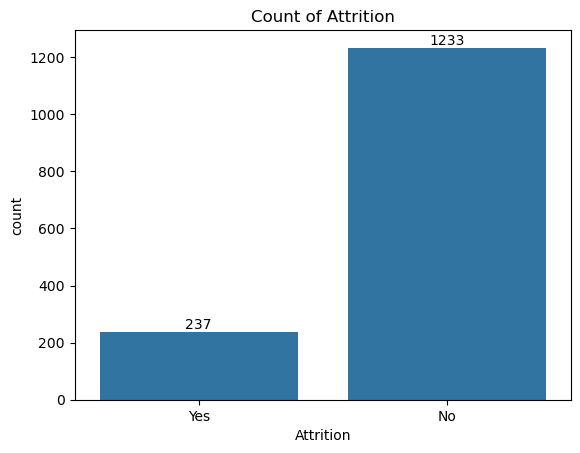

In [7]:

ax = sns.countplot(data=df, x='Attrition')
plt.title('Count of Attrition')

for container in ax.containers:
    ax.bar_label(container)
plt.show()

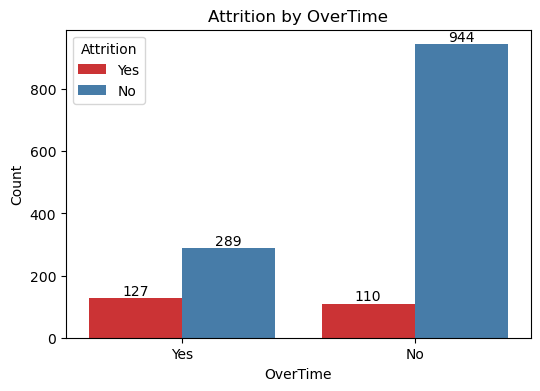

C:\Users\Vincent H\AppData\Local\Temp\ipykernel_12796\1672521512.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')


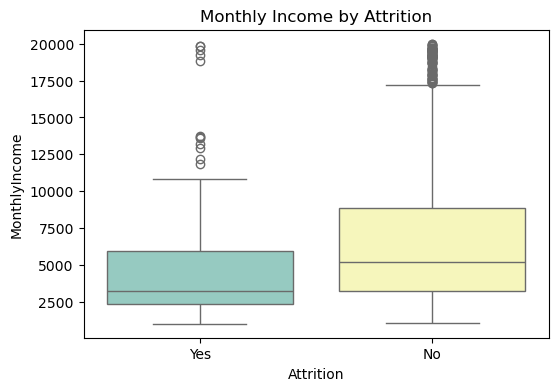

C:\Users\Vincent H\AppData\Local\Temp\ipykernel_12796\1672521512.py:16: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='JobSatisfaction', y=df['Attrition'].map({'No':0,'Yes':1}), palette='viridis',ci=None)
C:\Users\Vincent H\AppData\Local\Temp\ipykernel_12796\1672521512.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='JobSatisfaction', y=df['Attrition'].map({'No':0,'Yes':1}), palette='viridis',ci=None)


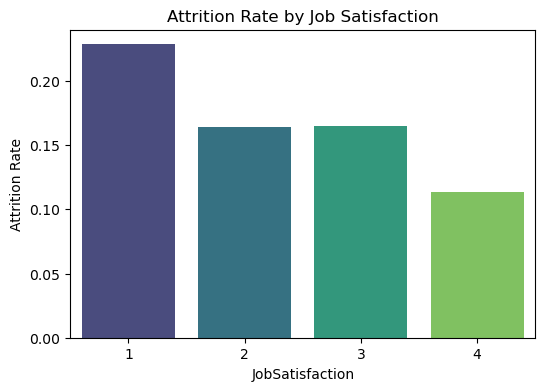

C:\Users\Vincent H\AppData\Local\Temp\ipykernel_12796\1672521512.py:25: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.lineplot(data=df_temp, x='YearsAtCompany', y='AttritionNum', estimator='mean', ci=None)


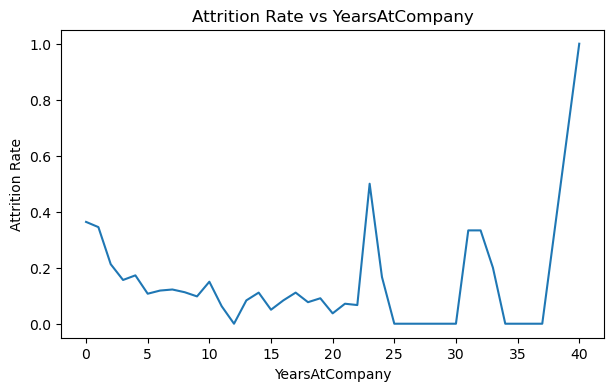

C:\Users\Vincent H\AppData\Local\Temp\ipykernel_12796\1672521512.py:32: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=None` for the same effect.

  sns.barplot(data=df, x='Department', y=df['Attrition'].map({'No':0,'Yes':1}), palette='Set2',ci=None)
C:\Users\Vincent H\AppData\Local\Temp\ipykernel_12796\1672521512.py:32: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df, x='Department', y=df['Attrition'].map({'No':0,'Yes':1}), palette='Set2',ci=None)


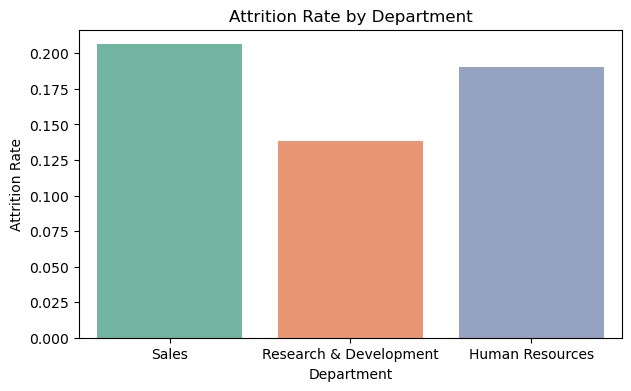

In [ ]:
plt.figure(figsize=(6,4))
sns.countplot(data=df, x='OverTime', hue='Attrition', palette='Set1')
plt.title("Attrition by OverTime")
plt.ylabel("Count")
for c in plt.gca().containers:
    plt.gca().bar_label(c)
plt.show()
plt.figure(figsize=(6,4))
sns.boxplot(data=df, x='Attrition', y='MonthlyIncome', palette='Set3')
plt.title("Monthly Income by Attrition")
plt.show()

plt.figure(figsize=(6,4))
sns.barplot(data=df, x='JobSatisfaction', y=df['Attrition'].map({'No':0,'Yes':1}), palette='viridis',ci=None)
plt.title("Attrition Rate by Job Satisfaction")
plt.ylabel("Attrition Rate")
plt.show()

df_temp = df.copy()
df_temp['AttritionNum'] = df_temp['Attrition'].map({'Yes':1,'No':0})

plt.figure(figsize=(7,4))
sns.lineplot(data=df_temp, x='YearsAtCompany', y='AttritionNum', estimator='mean', ci=None)
plt.title("Attrition Rate vs YearsAtCompany")
plt.ylabel("Attrition Rate")
plt.show()


plt.figure(figsize=(7,4))
sns.barplot(data=df, x='Department', y=df['Attrition'].map({'No':0,'Yes':1}), palette='Set2',ci=None)
plt.title("Attrition Rate by Department")
plt.ylabel("Attrition Rate")
plt.show()



# attrition by over time 
vertime shows to have the strongest relationship with attritions. Employees who are overtime are nearly 3 times higher than those who are not overtime. this shows that overtime may reflects poor work life balance and work preassure. making it a significant factor to employee to turnover

# Attrition by monthly income
Employee with low monthly income are likely to resign due to financial dissatisfaction. mean while employees who have high monthly income are having low attrition rates. showing that monthly income is crucial for the employee since they who have lower income tend to leave.

# Attrition rates by Job Satisfaction
The chart shows a negative relationship between Job Satisfaction and attrition. Employees with the lowest satisfaction level (1) exhibit the highest attrition rate, approximately 23%, while those with the highest satisfaction level (4) have the lowest attrition rate, around 11%. This indicates that as job satisfaction increases, the likelihood of resignation consistently decreases.

# Attrition rates vs Years at company
attrition rates at year 1 - 3 are quiet high, indicating early career employee are likely to leave. then attrition
rates at year 4 to 10 are low, indicating strong retention after the initial adjustment period. A small spike appears again around 20+ years, possibly due to stagnation or retirement-related decisions. at last year 40 shows significant spikes indicating employees are retiring 

# Attrition rates by department
sales department has the highest attrition rates around 20% this can be happen due to high work preassure and competitive work environment while research and development department is the most stable for around 13% attrition rates. this may suggest that attrition rates are also affect by departments


# feature encoding

In [9]:
df_encoded = df.copy()

from sklearn.preprocessing import OneHotEncoder
from sklearn.preprocessing import OrdinalEncoder

one_hot_mao = {
    'Attrition' : {'No' : 0, 'Yes' : 1},
    'Gender' : {'Female' : 0, 'Male' : 1},
    'OverTime' : {'No' : 0, 'Yes' : 1}
}

for col, mapping in one_hot_mao.items():
    df_encoded[col] = df_encoded[col].map(mapping)

nominal_cols = ['Department','EducationField','JobRole','MaritalStatus']
encoder = OrdinalEncoder()
df_encoded[nominal_cols] = encoder.fit_transform(df_encoded[nominal_cols])

ordinal_cols = ['BusinessTravel']
ordinal_encode = OrdinalEncoder(categories=[['Non-Travel','Travel_Rarely', 'Travel_Frequently']])
df_encoded[ordinal_cols] = encoder.fit_transform(df_encoded[ordinal_cols])

encode_dict = {}

for col, cats in zip(nominal_cols, encoder.categories_):
    encode_dict[col] = {category: int (code) for code,category in enumerate(cats)}

import pprint
pprint.pprint(encode_dict)

df_encoded.sample(n=5)

{'Department': {'Non-Travel': 0, 'Travel_Frequently': 1, 'Travel_Rarely': 2}}


,Age,Attrition,BusinessTravel,DailyRate,Department,DistanceFromHome,Education,EducationField,EnvironmentSatisfaction,Gender,...,PerformanceRating,RelationshipSatisfaction,StockOptionLevel,TotalWorkingYears,TrainingTimesLastYear,WorkLifeBalance,YearsAtCompany,YearsInCurrentRole,YearsSinceLastPromotion,YearsWithCurrManager
1259,30,0,2.0,305,1.0,16,3,1.0,3,1,...,3,3,1,10,3,3,7,0,1,7
385,30,1,1.0,464,1.0,4,3,5.0,3,1,...,4,3,0,3,4,3,1,0,0,0
643,42,0,2.0,1265,1.0,3,3,1.0,3,0,...,3,2,1,17,1,2,5,3,1,3
1221,45,0,0.0,1238,1.0,1,1,1.0,3,1,...,4,4,1,25,3,2,23,15,14,4
771,54,0,2.0,1082,2.0,2,4,1.0,3,0,...,3,2,1,13,4,3,9,4,7,0


In [10]:
y = df_encoded['Attrition']
X = df_encoded.drop('Attrition', axis=1)

# Logistic Regression


In [11]:
from sklearn.model_selection import train_test_split
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.3, random_state=0)

In [12]:
from sklearn.preprocessing import StandardScaler
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)        
X_test_scaled  = scaler.transform(X_test)              

In [13]:
from collections import Counter
from imblearn.over_sampling import SMOTE

X_train_scaled = pd.DataFrame(X_train_scaled, columns=X.columns, index=X_train.index)
X_test_scaled  = pd.DataFrame(X_test_scaled,  columns=X.columns, index=X_test.index)

print("Before SMOTE:", Counter(y_train))

sm = SMOTE(random_state=42, sampling_strategy='auto')
X_res, y_res = sm.fit_resample(X_train_scaled, y_train)

print("After SMOTE:", Counter(y_res))

Before SMOTE: Counter({0: 862, 1: 167})
After SMOTE: Counter({0: 862, 1: 862})


In [14]:
from sklearn.linear_model import LogisticRegression

model = LogisticRegression(max_iter=1000, random_state=42)
model.fit(X_res, y_res)

LogisticRegression(max_iter=1000, random_state=42)

[[289  82]
 [ 16  54]]
              precision    recall  f1-score   support

           0       0.95      0.78      0.86       371
           1       0.40      0.77      0.52        70

    accuracy                           0.78       441
   macro avg       0.67      0.78      0.69       441
weighted avg       0.86      0.78      0.80       441

ROC-AUC: 0.8474778590681555


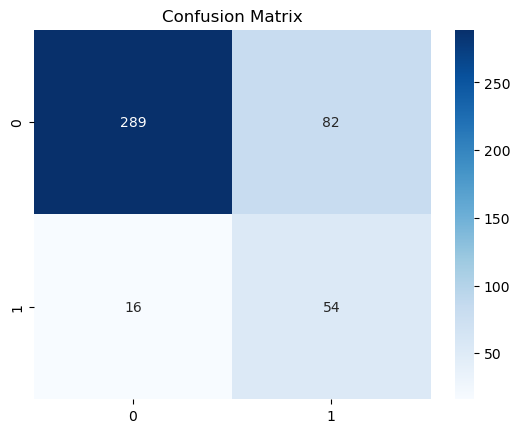

In [15]:
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score

y_pred = model.predict(X_test_scaled)
y_prob = model.predict_proba(X_test_scaled)[:,1]

print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))
print("ROC-AUC:", roc_auc_score(y_test, y_prob))

from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test, y_pred), annot=True, fmt="d", cmap="Blues")
plt.title("Confusion Matrix")
plt.show()


ROC-AUC Score: 0.8474778590681555


<Figure size 600x400 with 0 Axes>

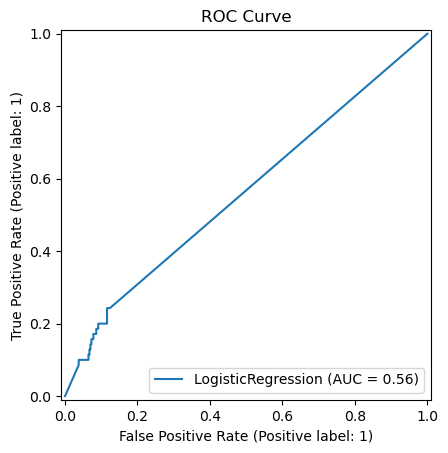

In [16]:
roc_auc = roc_auc_score(y_test, y_prob)
print("ROC-AUC Score:", roc_auc)
y_prob = model.predict_proba(X_test_scaled)[:, 1]

from sklearn.metrics import RocCurveDisplay
import matplotlib.pyplot as plt

plt.figure(figsize=(6,4))
RocCurveDisplay.from_estimator(model, X_test, y_test)
plt.title("ROC Curve")
plt.show()


d:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


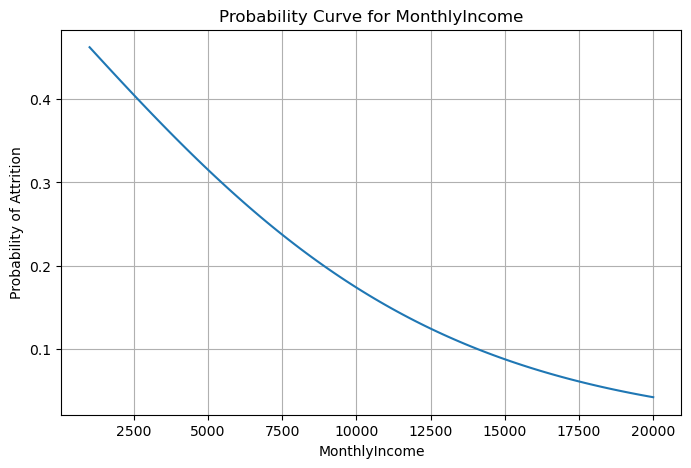

In [17]:

feature = "MonthlyIncome"
X_range = np.linspace(df[feature].min(), df[feature].max(), 100)

baseline = X_train.mean().to_frame().T
curve_data = pd.concat([baseline] * 100, ignore_index=True)

curve_data[feature] = X_range
curve_scaled = scaler.transform(curve_data)
y_curve_prob = model.predict_proba(curve_scaled)[:,1]

plt.figure(figsize=(8,5))
plt.plot(X_range, y_curve_prob)
plt.xlabel(feature)
plt.ylabel("Probability of Attrition")
plt.title(f"Probability Curve for {feature}")
plt.grid(True)
plt.show()


In [18]:
coef = pd.DataFrame({
    'Feature' : X.columns,
    'Coefficient' : model.coef_[0]
}).sort_values(by='Coefficient',ascending=False)

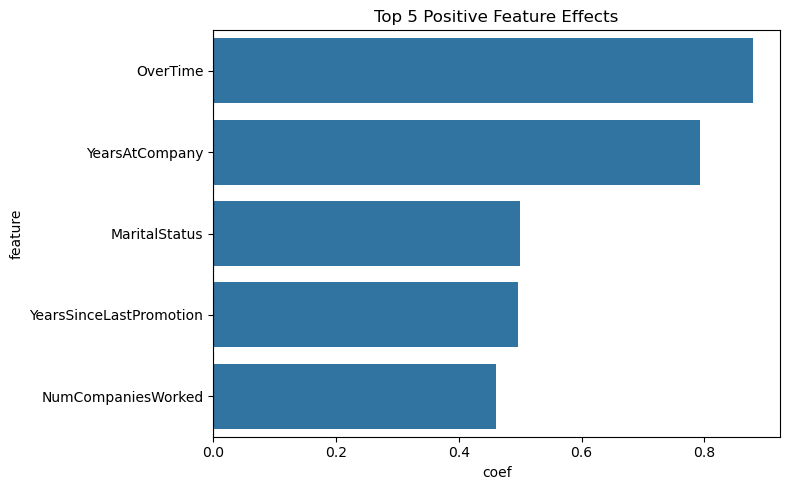

In [19]:
df_coef = pd.DataFrame({
    'feature': X.columns,
    'coef': model.coef_[0]
})

df_sorted = df_coef.sort_values('coef', ascending=False)

top5_pos = df_sorted.head(5)

df_top10 = pd.concat([top5_pos])

plt.figure(figsize=(8, 5))
sns.barplot(data=df_top10, x='coef', y='feature')
plt.axvline(0, linestyle="--", color="black")
plt.title("Top 5 Positive Feature Effects")
plt.tight_layout()
plt.show()



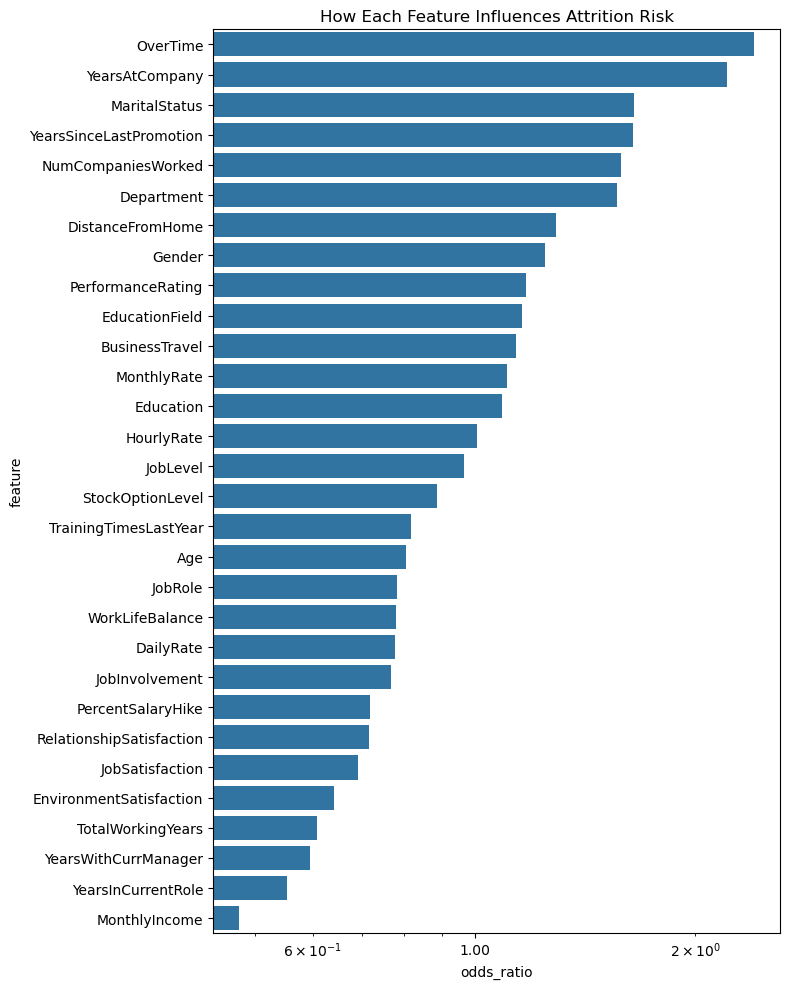

In [20]:

import matplotlib.ticker as ticker
df_or = df_coef.copy()
df_or['odds_ratio'] = np.exp(df_or['coef'])
df_or = df_or.sort_values('odds_ratio', ascending=False)

plt.figure(figsize=(8, 10))
sns.barplot(data=df_or, x='odds_ratio', y='feature')
plt.xscale('log')  
plt.gca().xaxis.set_major_formatter(ticker.FormatStrFormatter('%.2f'))
plt.title("How Each Feature Influences Attrition Risk")
plt.tight_layout()
plt.show()


Baseline mean probability: 0.3511438464878422
Baseline predicted attrition rate (%) (threshold 0.5): 31.088435374149658

Scenario A - Income+20% & OverTime->0
Mean predicted probability: 0.24192842449848154
Predicted attrition rate (%) (threshold 0.5): 16.666666666666664

Scenario B - Income+20% & OverTime reduced by 50 %
Mean predicted probability: 0.2839663713590656
Predicted attrition rate (%) (threshold 0.5): 22.380952380952383


d:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(
d:\Anaconda\Lib\site-packages\sklearn\base.py:493: UserWarning: X does not have valid feature names, but LogisticRegression was fitted with feature names
  warnings.warn(


,n,mean_prob,predicted_rate_percent,preds_count
description,,,,
baseline (original),1470,0.351144,31.088435,457
Income+20% & OverTime->0,1470,0.241928,16.666667,245
Income+20% & OverTime reduced by 50%,1470,0.283966,22.380952,329



Changes vs baseline (Scenario A): mean_prob Δ=-0.1092, pred_rate Δ=-14.42 pct
Changes vs baseline (Scenario B): mean_prob Δ=-0.0672, pred_rate Δ=-8.71 pct


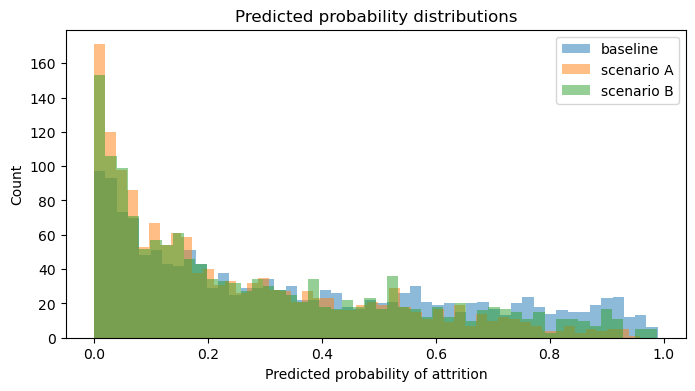

In [23]:
def evaluate_simulation(X_orig, description="scenario"):
    """
    X_orig: DataFrame with same columns as model input (unscaled)
    returns dict with mean probability, predicted rate, counts
    """
    # scale using existing scaler
    X_scaled = scaler.transform(X_orig)               
    # predict probabilities and classes
    probs = model.predict_proba(X_scaled)[:, 1]
    preds = (probs >= 0.5).astype(int)                
    result = {
        'description': description,
        'mean_prob': probs.mean(),
        'predicted_rate_percent': preds.mean() * 100,
        'preds_count': preds.sum(),
        'n': len(preds)
    }
    return result, probs, preds
# baseline (original data)
X = df_encoded.drop(columns=['Attrition']).copy()
y = df_encoded['Attrition'].copy()

baseline_res, baseline_probs, baseline_preds = evaluate_simulation(X, description="baseline (original)")
print("Baseline mean probability:", baseline_res['mean_prob'])
print("Baseline predicted attrition rate (%) (threshold 0.5):", baseline_res['predicted_rate_percent'])

#  Scenario A: MonthlyIncome +20% & set OverTime -> 0 
X_a = X.copy()
if 'MonthlyIncome' not in X_a.columns or 'OverTime' not in X_a.columns:
    raise ValueError("MonthlyIncome or OverTime column not found in X.")

# increase income by 20%
X_a['MonthlyIncome'] = X_a['MonthlyIncome'] * 1.20

# set overtime to 0 for everyone (full reduction)
X_a['OverTime'] = 0

res_a, probs_a, preds_a = evaluate_simulation(X_a, description="Income+20% & OverTime->0")
print("\nScenario A - Income+20% & OverTime->0")
print("Mean predicted probability:", res_a['mean_prob'])
print("Predicted attrition rate (%) (threshold 0.5):", res_a['predicted_rate_percent'])

#  Scenario B: MonthlyIncome +20% & reduce OverTime by pct 
pct_reduce = 0.5   # 50% reduction of employees who currently do overtime
X_b = X.copy()

# increase income by 20%
X_b['MonthlyIncome'] = X_b['MonthlyIncome'] * 1.20

# reduce overtime by randomly switching off fraction of current overtime=1 rows
rng = np.random.RandomState(42)   
idx_overtime = X_b[X_b['OverTime'] == 1].index
n_to_switch = int(len(idx_overtime) * pct_reduce)
to_switch = rng.choice(idx_overtime, size=n_to_switch, replace=False)
X_b.loc[to_switch, 'OverTime'] = 0

res_b, probs_b, preds_b = evaluate_simulation(X_b, description=f"Income+20% & OverTime reduced by {int(pct_reduce*100)}%")
print("\nScenario B - Income+20% & OverTime reduced by", int(pct_reduce*100), "%")
print("Mean predicted probability:", res_b['mean_prob'])
print("Predicted attrition rate (%) (threshold 0.5):", res_b['predicted_rate_percent'])
summary = pd.DataFrame([
    baseline_res,
    res_a,
    res_b
])[['description','n','mean_prob','predicted_rate_percent','preds_count']]

summary = summary.set_index('description')
display(summary)


delta_mean_prob_A = res_a['mean_prob'] - baseline_res['mean_prob']
delta_pred_rate_A = res_a['predicted_rate_percent'] - baseline_res['predicted_rate_percent']

delta_mean_prob_B = res_b['mean_prob'] - baseline_res['mean_prob']
delta_pred_rate_B = res_b['predicted_rate_percent'] - baseline_res['predicted_rate_percent']

print("\nChanges vs baseline (Scenario A): mean_prob Δ={:.4f}, pred_rate Δ={:.2f} pct".format(delta_mean_prob_A, delta_pred_rate_A))
print("Changes vs baseline (Scenario B): mean_prob Δ={:.4f}, pred_rate Δ={:.2f} pct".format(delta_mean_prob_B, delta_pred_rate_B))


import matplotlib.pyplot as plt
plt.figure(figsize=(8,4))
plt.hist(baseline_probs, bins=50, alpha=0.5, label='baseline')
plt.hist(probs_a, bins=50, alpha=0.5, label='scenario A')
plt.hist(probs_b, bins=50, alpha=0.5, label='scenario B')
plt.legend()
plt.xlabel('Predicted probability of attrition')
plt.ylabel('Count')
plt.title('Predicted probability distributions')
plt.show()
